# IoMT Ransomware Detection — Pipeline Demo

**Dataset:** CICIoMT2024 (University of New Brunswick) + Simulated ICU
**Pipeline:** Autoencoder anomaly scoring → Mamba sequence classification


In [22]:
import os, sys, glob
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

sys.path.insert(0, os.path.abspath('.'))
from src.config import Config
from src.models.autoencoder import Autoencoder
from src.models.mamba_classifier import MambaClassifier
from src.datasets.sequence_dataset import ArraySequenceDataset
from src.evaluate.metrics import find_optimal_threshold, compute_metrics

cfg    = Config()
device = torch.device('cpu')
np.random.seed(42)
print('Ready.')


Ready.


---
## The Data — CICIoMT2024 (University of New Brunswick)

This is real network traffic captured from a simulated hospital environment.
Each row is one network connection between medical devices — things like patient monitors,
infusion pumps, and ECG machines communicating over WiFi.
The dataset contains both normal device communication and 17 types of attacks including ransomware.


In [23]:
# Load a sample of the CIC raw data to show what we are working with
# Label is derived from the filename: 'benign' in name -> 0, else -> 1
files = glob.glob('data/raw/cic_raw/wifi_mqtt/**/*.csv', recursive=True)
dfs = []
for f in files[:4]:
    df = pd.read_csv(f, low_memory=False, nrows=200)
    df['label'] = 0 if 'benign' in os.path.basename(f).lower() else 1
    df['traffic_type'] = os.path.basename(f).replace('.pcap.csv','').replace('_train','').replace('_test','')
    dfs.append(df)
cic_sample = pd.concat(dfs, ignore_index=True)

print(f'Features per connection : {cic_sample.shape[1] - 2}  (label and traffic_type added by us)')
print(f'Example features        : {list(cic_sample.columns[:8])}')
print()

# Show a few raw rows
display(cic_sample[['traffic_type','Header_Length','Protocol Type','Duration','Rate','Srate','fin_flag_number','syn_flag_number','label']].head(6))


Features per connection : 45  (label and traffic_type added by us)
Example features        : ['Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number']



,traffic_type,Header_Length,Protocol Type,Duration,Rate,Srate,fin_flag_number,syn_flag_number,label
0,ARP_Spoofing,866.6,10.4,64.0,45722.390222,45722.390222,0.0,0.0,1
1,ARP_Spoofing,3934.3,12.6,131.2,35708.799475,35708.799475,0.0,0.0,1
2,ARP_Spoofing,5592.8,12.6,97.6,66.403506,66.403506,0.0,0.0,1
3,ARP_Spoofing,9303.6,14.8,80.8,51.201280,51.201280,0.0,0.0,1
4,ARP_Spoofing,8592.4,12.6,98.6,42.706455,42.706455,0.0,0.0,1
5,ARP_Spoofing,12734.7,14.8,76.8,42.891720,42.891720,0.0,0.0,1


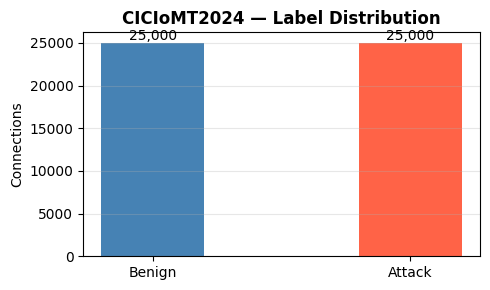

In [24]:
# Label distribution across the full CIC dataset
sp = cfg.cic_splits_path
y_all = np.concatenate([
    np.load(os.path.join(sp, f'{s}.npy')) for s in ['y_train','y_val','y_test']
])

fig, ax = plt.subplots(figsize=(5, 3))
counts = [int((y_all==0).sum()), int((y_all==1).sum())]
bars   = ax.bar(['Benign', 'Attack'], counts, color=['steelblue','tomato'], width=0.4)
ax.bar_label(bars, fmt='{:,.0f}')
ax.set_title('CICIoMT2024 — Label Distribution', fontweight='bold')
ax.set_ylabel('Connections')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


---
## Stage 1 — Preprocessing

Raw network logs cannot be fed directly into a neural network.
We drop non-feature columns, replace invalid values, and apply StandardScaler so every
feature has mean 0 and standard deviation 1.

The data is then split **70% train / 15% validation / 15% test**.
The split is group-aware — all connections from the same device stay in the same split,
preventing the model from memorising device-specific patterns.

```python
# Key preprocessing steps
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_df)   # fit on train only
X_val   = scaler.transform(X_val_df)         # apply same scale to val
X_test  = scaler.transform(X_test_df)        # apply same scale to test

# Group-aware split — keeps all connections from one device in one split
gss = GroupShuffleSplit(n_splits=1, test_size=0.15)
trainval_idx, test_idx = next(gss.split(X, y, groups=device_ids))
```


In [25]:
# Load the preprocessed CIC splits and show what comes out
sp = cfg.cic_splits_path
X_train = np.load(os.path.join(sp,'X_train.npy'))
X_val   = np.load(os.path.join(sp,'X_val.npy'))
X_test  = np.load(os.path.join(sp,'X_test.npy'))
y_train = np.load(os.path.join(sp,'y_train.npy'))
y_val   = np.load(os.path.join(sp,'y_val.npy'))
y_test  = np.load(os.path.join(sp,'y_test.npy'))

total = len(X_train)+len(X_val)+len(X_test)
print(f'Input features per connection : {X_train.shape[1]}')
print()
print(f'{"Split":<8} {"Connections":>14}  {"Benign":>10}  {"Attack":>10}')
print('-'*46)
for name,X,y in [("Train",X_train,y_train),("Val",X_val,y_val),("Test",X_test,y_test)]:
    print(f'{name:<8} {len(X):>14,}  {int((y==0).sum()):>10,}  {int((y==1).sum()):>10,}')
print()

# Compare raw vs scaled values for 4 features as a table
import glob
files = glob.glob('data/raw/cic_raw/wifi_mqtt/**/*.csv', recursive=True)
raw_dfs = []
for f in files[:4]:
    raw_dfs.append(pd.read_csv(f, low_memory=False, nrows=500))
raw_df_sample = pd.concat(raw_dfs, ignore_index=True)

feature_names = ['Header_Length', 'Rate', 'IAT', 'Tot sum']
col_names     = list(raw_df_sample.columns)
rows = []
for feat in feature_names:
    if feat in col_names:
        idx     = col_names.index(feat)
        raw_col = raw_df_sample[feat].dropna()
        sc_col  = X_train[:, idx]
        rows.append({
            'Feature':       feat,
            'Raw Min':       f'{raw_col.min():,.0f}',
            'Raw Max':       f'{raw_col.max():,.0f}',
            'Raw Mean':      f'{raw_col.mean():,.1f}',
            'Scaled Min':    f'{sc_col.min():.2f}',
            'Scaled Max':    f'{sc_col.max():.2f}',
            'Scaled Mean':   f'{sc_col.mean():.3f}',
        })

comparison_df = pd.DataFrame(rows)
print("Feature value ranges before and after StandardScaler:")
display(comparison_df)


Input features per connection : 45

Split       Connections      Benign      Attack
----------------------------------------------
Train            34,950      17,700      17,250
Val               7,550       3,850       3,700
Test              7,500       3,450       4,050

Feature value ranges before and after StandardScaler:


,Feature,Raw Min,Raw Max,Raw Mean,Scaled Min,Scaled Max,Scaled Mean
0,Header_Length,79,"1,532,673","134,483.5",-0.29,11.39,-0.000
1,Rate,0,"549,633","2,824.1",-0.20,28.91,-0.000
2,IAT,0,"169,464,107","84,882,969.8",-1.29,1.28,0.000
3,Tot sum,285,"18,813","2,701.3",-0.40,7.11,0.000


---
## Stage 2 — Autoencoder

The autoencoder is trained **on benign traffic only**.
It learns to compress and reconstruct normal device behaviour.
When attack traffic is passed through it, reconstruction quality drops — producing a high error.
This error is our anomaly score.

```python
class Autoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim1=128, hidden_dim2=64, latent_dim=32):
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1), nn.ReLU(),
            nn.Linear(hidden_dim1, hidden_dim2), nn.ReLU(),
            nn.Linear(hidden_dim2, latent_dim)        # compress to 32 dims
        )
        self.decoder = nn.Sequential(...)             # mirror of encoder

    def forward(self, x):
        z     = self.encoder(x)                       # 32-dim latent vector
        x_hat = self.decoder(z)                       # reconstructed input
        return z, x_hat
```

**Input:** 45 raw features per connection
**Output:** 32-dim latent vector + 1 reconstruction error = **33-dim representation**


In [27]:
# Load the trained CIC autoencoder
ae = Autoencoder(
    input_dim=X_train.shape[1],
    hidden_dim1=cfg.ae_hidden_dim1, hidden_dim2=cfg.ae_hidden_dim2,
    latent_dim=cfg.latent_dim
).to(device)
ae.load_state_dict(torch.load(cfg.cic_autoencoder_model_path, map_location=device))
ae.eval()

# Pass one benign and one attack sample through to show the difference
benign_sample = torch.tensor(X_test[y_test==0][:1], dtype=torch.float32)
attack_sample = torch.tensor(X_test[y_test==1][:1], dtype=torch.float32)

with torch.no_grad():
    z_b, xhat_b = ae(benign_sample)
    z_a, xhat_a = ae(attack_sample)

err_b = torch.mean((benign_sample - xhat_b)**2).item()
err_a = torch.mean((attack_sample - xhat_a)**2).item()

print('                     Input shape    Latent shape   Recon Error')
print(f'  Benign connection:  {tuple(benign_sample.shape)}       {tuple(z_b.shape)}        {err_b:.5f}')
print(f'  Attack connection:  {tuple(attack_sample.shape)}       {tuple(z_a.shape)}        {err_a:.5f}')
print(f'\n  Attack error is {err_a/err_b:.1f}x higher than benign error')


                     Input shape    Latent shape   Recon Error
  Benign connection:  (1, 45)       (1, 32)        0.00034
  Attack connection:  (1, 45)       (1, 32)        0.05282

  Attack error is 157.6x higher than benign error


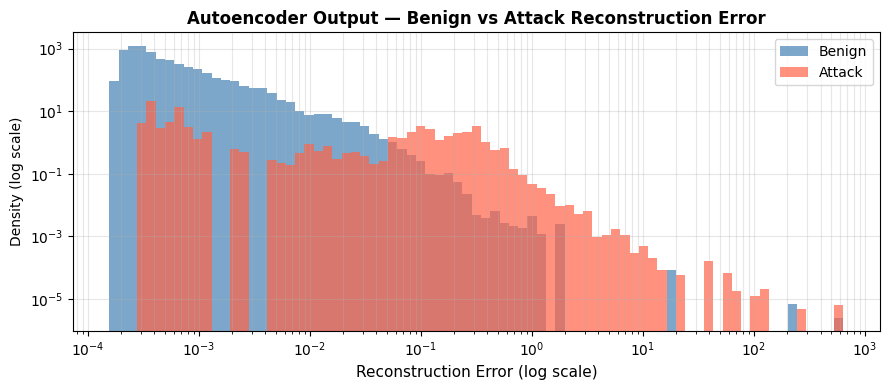

Attack traffic is harder for the autoencoder to reconstruct — producing higher errors.


In [28]:
# Show reconstruction error distribution across the full test set
def get_errors(ae, X, batch_size=512):
    errs = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            b = torch.tensor(X[i:i+batch_size], dtype=torch.float32)
            _, xh = ae(b)
            errs.append(torch.mean((b-xh)**2, dim=1).numpy())
    return np.concatenate(errs)

errs = get_errors(ae, X_test)

log_bins = np.logspace(np.log10(errs[errs > 0].min()), np.log10(errs.max()), 80)

fig, ax = plt.subplots(figsize=(9,4))
ax.hist(errs[y_test==0], bins=log_bins, alpha=0.7, color='steelblue', density=True, label='Benign')
ax.hist(errs[y_test==1], bins=log_bins, alpha=0.7, color='tomato',    density=True, label='Attack')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Reconstruction Error (log scale)', fontsize=11)
ax.set_ylabel('Density (log scale)')
ax.set_title('Autoencoder Output — Benign vs Attack Reconstruction Error', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout(); plt.show()
print('Attack traffic is harder for the autoencoder to reconstruct — producing higher errors.')

---
## Stage 3 — Sequence Construction

A single high reconstruction error could just be noise.
Ransomware produces **sustained** anomalous behaviour over time.

We build a sliding window of **20 consecutive timesteps** for each device.
Each window becomes one input to the classifier — capturing the temporal pattern, not just a single moment.

```python
# Slide a window of 20 steps across each device's timeline
for i in range(len(device_rows) - seq_len + 1):
    window = encoded_features[i : i + 20]   # shape (20, 33)
    label  = labels[i + 19]                 # label of the last timestep
    sequences.append(window)
```

**Input:** N encoded timesteps (33-dim each)
**Output:** sequences of shape **(20 × 33)**


Encoded timestep shape : (6000, 33)   (connections x 33 features)
Sequence shape         : (20, 33)       (20 timesteps x 33 features)
Total test sequences   : 5,772
  Benign sequences     : 4,272
  Attack sequences     : 1,500


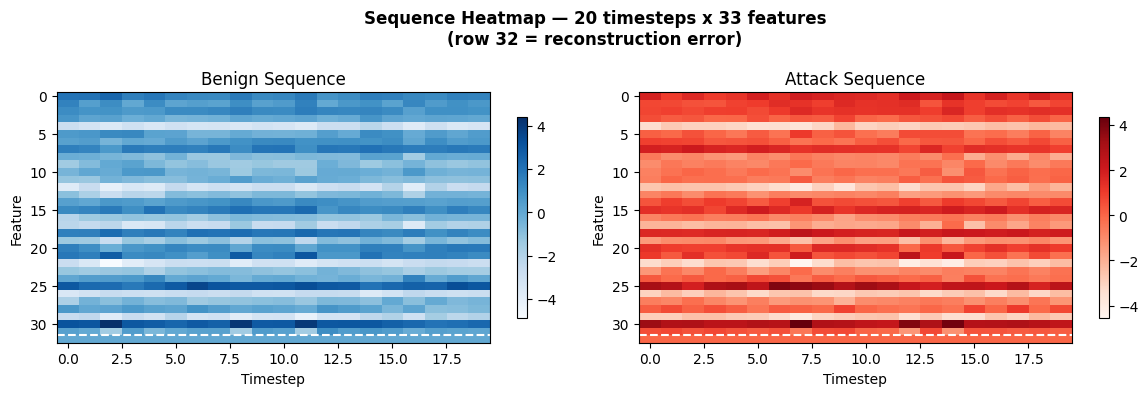

In [29]:
# Switch to SIM dataset for sequence construction and classification
# SIM has named device IDs which we use in the final predictions
sp_sim   = cfg.sim_splits_path
X_tr_sim = np.load(os.path.join(sp_sim,'X_train.npy'))
X_te_sim = np.load(os.path.join(sp_sim,'X_test.npy'))
y_tr_sim = np.load(os.path.join(sp_sim,'y_train.npy'))
y_te_sim = np.load(os.path.join(sp_sim,'y_test.npy'))
g_te_sim = np.load(os.path.join(sp_sim,'group_ids_test.npy'), allow_pickle=True)

# Load SIM autoencoder and encode the test split
ae_sim = Autoencoder(X_tr_sim.shape[1], cfg.ae_hidden_dim1, cfg.ae_hidden_dim2, cfg.latent_dim).to(device)
ae_sim.load_state_dict(torch.load(cfg.sim_autoencoder_model_path, map_location=device))
ae_sim.eval()

def encode(ae, X, bs=512):
    out = []
    with torch.no_grad():
        for i in range(0, len(X), bs):
            b = torch.tensor(X[i:i+bs], dtype=torch.float32)
            z, xh = ae(b)
            err = torch.mean((b-xh)**2, dim=1, keepdim=True)
            out.append(torch.cat([z, err], dim=1).numpy())
    return np.vstack(out)

Z_te_sim = encode(ae_sim, X_te_sim)

# Build sequence dataset
test_ds = ArraySequenceDataset(Z_te_sim, y_te_sim, g_te_sim, cfg.seq_len, label_mode='any')

print(f'Encoded timestep shape : {Z_te_sim.shape}   (connections x 33 features)')
print(f'Sequence shape         : {tuple(test_ds[0][0].shape)}       (20 timesteps x 33 features)')
print(f'Total test sequences   : {len(test_ds):,}')
print(f'  Benign sequences     : {int((test_ds.labels==0).sum()):,}')
print(f'  Attack sequences     : {int((test_ds.labels==1).sum()):,}')

# Show one sequence as a heatmap
fig, (a1,a2) = plt.subplots(1,2,figsize=(12,4))
fig.suptitle('Sequence Heatmap — 20 timesteps x 33 features\n(row 32 = reconstruction error)',
             fontweight='bold')
for ax, idx, title, cmap in [
    (a1, int(np.where(test_ds.labels.numpy()==0)[0][5]), 'Benign Sequence',  'Blues'),
    (a2, int(np.where(test_ds.labels.numpy()==1)[0][5]), 'Attack Sequence',  'Reds'),
]:
    seq = test_ds[idx][0].numpy()
    im  = ax.imshow(seq.T, aspect='auto', cmap=cmap, interpolation='nearest')
    ax.axhline(31.5, color='white', linewidth=1.5, linestyle='--')
    ax.set_xlabel('Timestep'); ax.set_ylabel('Feature')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()


---
## Stage 4 — Mamba Classifier

The Mamba classifier receives a 20-step sequence and outputs a single probability: **how likely is this sequence to be ransomware?**

Mamba is a Selective State Space Model — it processes the sequence step by step,
maintaining a hidden state that selectively retains what matters and forgets what doesn't.
This makes it well suited to detecting the sustained, evolving patterns of a ransomware attack.

```python
class MambaClassifier(nn.Module):
    def forward(self, x):                        # x: (batch, 20, 33)
        x = self.input_projection(x)             # project to hidden dim
        for layer in self.mamba_layers:
            x = layer(x)                         # selective state-space recurrence
        x = x.mean(dim=1)                        # pool across time
        return self.classifier(x)               # single logit per sequence
```

**Input:** sequence (20 × 33)
**Output:** probability of ransomware (0 → benign, 1 → attack)


Decision threshold : 0.55
F1 Score           : 0.9694
AUC-ROC            : 0.9787
Recall             : 0.9407  (attacks caught)
FPR                : 0.0000  (false alarms)


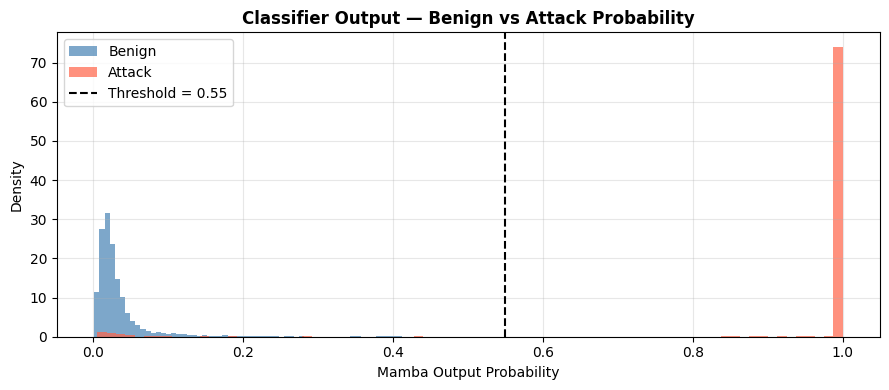

In [30]:
# Load the trained Mamba classifier
model = MambaClassifier(
    input_dim=cfg.latent_dim+1, d_model=cfg.d_model,
    n_layers=cfg.num_layers, dropout=cfg.dropout
).to(device)
model.load_state_dict(torch.load(cfg.sim_classifier_model_path, map_location=device))
model.eval()

# Run all test sequences through the classifier
loader = DataLoader(test_ds, batch_size=256, shuffle=False)
all_probs, all_labels = [], []
with torch.no_grad():
    for xb, yb in loader:
        all_probs.append(torch.sigmoid(model(xb.to(device))).cpu().numpy())
        all_labels.append(yb.numpy())
all_probs  = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels).astype(int)

threshold = find_optimal_threshold(all_labels, all_probs)
y_pred    = (all_probs >= threshold).astype(int)
metrics   = compute_metrics(all_labels, y_pred, all_probs)

print(f'Decision threshold : {threshold:.2f}')
print(f'F1 Score           : {metrics["f1"]:.4f}')
print(f'AUC-ROC            : {metrics["auc_roc"]:.4f}')
print(f'Recall             : {metrics["recall"]:.4f}  (attacks caught)')
print(f'FPR                : {metrics["fpr"]:.4f}  (false alarms)')

# Output probability distribution
fig, ax = plt.subplots(figsize=(9,4))
ax.hist(all_probs[all_labels==0], bins=80, alpha=0.7, color='steelblue', density=True, label='Benign')
ax.hist(all_probs[all_labels==1], bins=80, alpha=0.7, color='tomato',    density=True, label='Attack')
ax.axvline(threshold, color='black', linestyle='--', linewidth=1.5, label=f'Threshold = {threshold:.2f}')
ax.set_xlabel('Mamba Output Probability'); ax.set_ylabel('Density')
ax.set_title('Classifier Output — Benign vs Attack Probability', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


---
## Predicted Attacks — Devices Flagged as Ransomware

For each device in the test set we count how many of its sequences were predicted as an attack.
A device is flagged if **any** of its sequences exceed the decision threshold.


In [31]:
# For each device, compute what fraction of its sequences were predicted as attack
# and the maximum confidence the model expressed for any of its sequences.

# Rebuild per-sequence group ID mapping from the dataset
seq_group_ids = []
from src.datasets.sequence_dataset import ArraySequenceDataset as ASD
import numpy as np

unique_groups, group_indices = np.unique(g_te_sim, return_inverse=True)
group_to_rows = {g: [] for g in range(len(unique_groups))}
for row_idx, grp_idx in enumerate(group_indices):
    group_to_rows[grp_idx].append(row_idx)

seq_idx = 0
for grp_idx, rows in group_to_rows.items():
    if len(rows) < cfg.seq_len:
        continue
    n_windows = len(rows) - cfg.seq_len + 1
    for _ in range(n_windows):
        seq_group_ids.append(unique_groups[grp_idx])
    seq_idx += n_windows

seq_group_ids = np.array(seq_group_ids[:len(all_probs)])

# Aggregate per device
rows = []
for device in np.unique(seq_group_ids):
    mask         = seq_group_ids == device
    n_seqs       = mask.sum()
    n_flagged    = y_pred[mask].sum()
    max_prob     = all_probs[mask].max()
    true_label   = 'ATTACK' if 'attack' in device else 'normal'
    predicted    = 'ATTACK' if n_flagged > 0 else 'normal'
    rows.append({
        'Device':          device,
        'True Label':      true_label,
        'Seqs Flagged':    f'{n_flagged}/{n_seqs}',
        'Max Probability': f'{max_prob:.3f}',
        'Prediction':      predicted,
        'Correct':         'YES' if true_label == predicted else 'NO'
    })

results_df = pd.DataFrame(rows).sort_values(['True Label','Device'], ascending=[False,True])

# Colour-code: show attack devices first
attack_rows = results_df[results_df['Prediction']=='ATTACK']
normal_rows = results_df[results_df['Prediction']=='normal']

print(f'Devices predicted as ATTACK ({len(attack_rows)}):')
display(attack_rows.reset_index(drop=True))
print(f'\nDevices predicted as normal ({len(normal_rows)}):')
display(normal_rows.reset_index(drop=True))


Devices predicted as ATTACK (5):


,Device,True Label,Seqs Flagged,Max Probability,Prediction,Correct
0,infusion_pump_attack_0,ATTACK,281/481,1.000,ATTACK,YES
1,infusion_pump_attack_4,ATTACK,281/481,1.000,ATTACK,YES
2,iomt_gateway_attack_2,ATTACK,286/481,1.000,ATTACK,YES
3,iomt_gateway_attack_8,ATTACK,280/481,1.000,ATTACK,YES
4,patient_monitor_attack_9,ATTACK,283/481,1.000,ATTACK,YES



Devices predicted as normal (7):


,Device,True Label,Seqs Flagged,Max Probability,Prediction,Correct
0,infusion_pump_normal_0,normal,0/481,0.548,normal,YES
1,infusion_pump_normal_2,normal,0/481,0.404,normal,YES
2,infusion_pump_normal_8,normal,0/481,0.089,normal,YES
3,iomt_gateway_normal_0,normal,0/481,0.073,normal,YES
4,iomt_gateway_normal_1,normal,0/481,0.277,normal,YES
5,iomt_gateway_normal_3,normal,0/481,0.308,normal,YES
6,ventilator_normal_0,normal,0/481,0.162,normal,YES


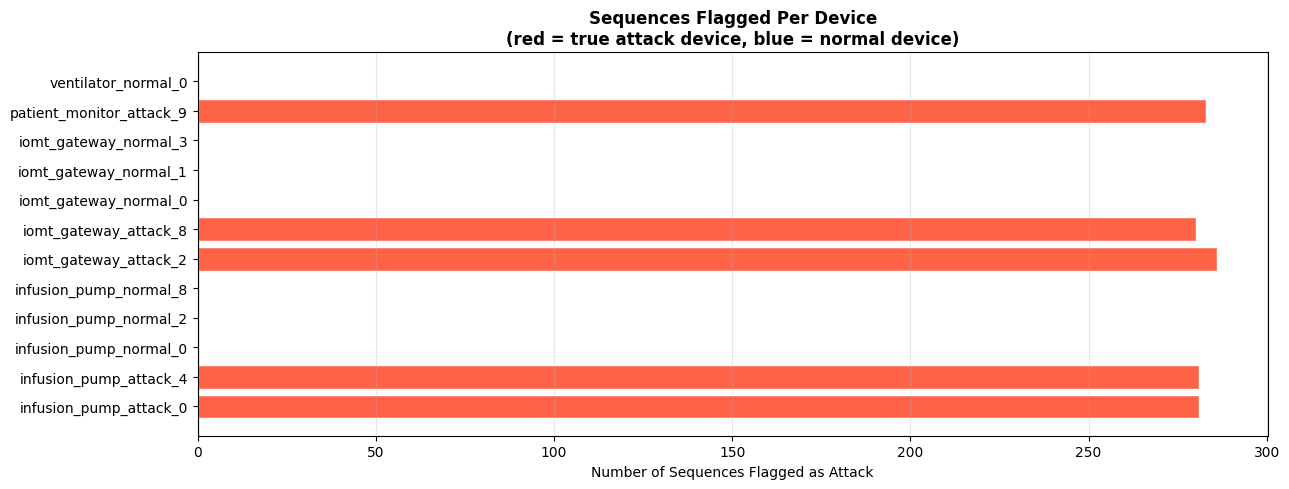

In [32]:
# Summary bar chart — sequences flagged per device
fig, ax = plt.subplots(figsize=(13, 5))

devices  = [r['Device'] for r in rows]
flagged  = [int(r['Seqs Flagged'].split('/')[0]) for r in rows]
colors   = ['tomato' if 'attack' in d else 'steelblue' for d in devices]

bars = ax.barh(devices, flagged, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Number of Sequences Flagged as Attack')
ax.set_title('Sequences Flagged Per Device\n(red = true attack device, blue = normal device)',
             fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()
